In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data=pd.read_csv(r"C:\Users\mahes\Desktop\python_projects\Emp_attrition_csv.csv")

In [4]:
data.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure (In Months),Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89.0,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21.0,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74.0,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50.0,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68.0,No,No,No,Fair,Medium,Stayed


In [5]:
data['Tenure']=data['Years at Company']

In [6]:
data.columns

Index(['Employee ID', 'Age', 'Gender', 'Years at Company', 'Job Role',
       'Monthly Income', 'Work-Life Balance', 'Job Satisfaction',
       'Performance Rating', 'Number of Promotions', 'Overtime',
       'Distance from Home', 'Education Level', 'Marital Status',
       'Number of Dependents', 'Job Level', 'Company Size',
       'Company Tenure (In Months)', 'Remote Work', 'Leadership Opportunities',
       'Innovation Opportunities', 'Company Reputation',
       'Employee Recognition', 'Attrition', 'Tenure'],
      dtype='object')

In [7]:
data.drop(['Employee ID','Company Tenure (In Months)','Education Level',
           'Marital Status','Years at Company',
           'Company Reputation','Employee Recognition','Number of Dependents',
           'Job Level','Innovation Opportunities',
           'Company Size'],axis=1,inplace=True)

**Check If there any null & duplicate values in the dataset**

In [8]:
data.isna().sum()

Age                            0
Gender                         0
Job Role                       0
Monthly Income                 0
Work-Life Balance              0
Job Satisfaction               0
Performance Rating             0
Number of Promotions           0
Overtime                       0
Distance from Home          1912
Remote Work                    0
Leadership Opportunities       0
Attrition                      0
Tenure                         0
dtype: int64

In [9]:
data.duplicated().sum()

np.int64(112)

**Drop The Null And Duplicate values**

In [10]:
data.drop_duplicates(inplace=True)

In [11]:
data.dropna(subset=['Distance from Home'],inplace=True)

**Checing the any unsual salaries in the data**

In [12]:
Q1=data['Monthly Income'].quantile(0.25)
Q3=data['Monthly Income'].quantile(0.75)
IQR=Q3-Q1
Lower_bound=Q1-1.5*IQR
Upper_bound=Q3+1.5*IQR
outliers=data[(data['Monthly Income']<Lower_bound) | (data['Monthly Income']>Upper_bound)]
print(f"Number of outliers: {outliers.shape[0]}")

Number of outliers: 146


In [18]:
print(Q1)
print(Q3)
print(IQR)
print(Lower_bound)
print(Upper_bound)

5653.0
8877.0
3224.0
817.0
13713.0


In [15]:
print(outliers[['Tenure','Monthly Income']])

       Tenure  Monthly Income
387        14           15495
477        11           50000
481        14           50000
545         1           50000
562        12           50000
...       ...             ...
67976      32           13764
68241      14           14707
69990       4           14433
72273      34           14547
74052      27           15063

[146 rows x 2 columns]


**Percentage count of left and stayed employees**

In [12]:
data['Attrition'].value_counts(normalize=True)

Attrition
Stayed    0.524566
Left      0.475434
Name: proportion, dtype: float64

**Attrition Rate By Job Role**

In [13]:
total_emp_by_role=data.groupby('Job Role')['Attrition'].value_counts()
total_emp_by_role

Job Role    Attrition
Education   Stayed       7806
            Left         7462
Finance     Stayed       5409
            Left         4779
Healthcare  Stayed       8739
            Left         7901
Media       Stayed       6184
            Left         5487
Technology  Stayed       9946
            Left         8888
Name: count, dtype: int64

In [14]:
data['Attrition Rate']=data['Attrition'].apply(lambda x: 1 if x=='Left' else 0)

In [15]:
data.head()

,Age,Gender,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,Distance from Home,Remote Work,Leadership Opportunities,Attrition,Tenure,Attrition Rate
0,31,Male,Education,5390,Excellent,Medium,Average,2,No,22.0,No,No,Stayed,19,0
1,59,Female,Media,5534,Poor,High,Low,3,No,21.0,No,No,Stayed,4,0
2,24,Female,Healthcare,8159,Good,High,Low,0,No,11.0,No,No,Stayed,10,0
3,36,Female,Education,3989,Good,High,High,1,No,27.0,Yes,No,Stayed,7,0
4,56,Male,Education,4821,Fair,Very High,Average,0,Yes,71.0,No,No,Stayed,41,0


In [16]:
left_emp_by_role=data[data['Attrition Rate']==1].groupby('Job Role')['Attrition'].count()
left_emp_by_role

Job Role
Education     7462
Finance       4779
Healthcare    7901
Media         5487
Technology    8888
Name: Attrition, dtype: int64

In [17]:
Attrition_rate_by_role=(left_emp_by_role/total_emp_by_role)*100
Attrition_rate_by_role.round(2)

Job Role    Attrition
Education   Stayed        95.59
            Left         100.00
Finance     Stayed        88.35
            Left         100.00
Healthcare  Stayed        90.41
            Left         100.00
Media       Stayed        88.73
            Left         100.00
Technology  Stayed        89.36
            Left         100.00
dtype: float64

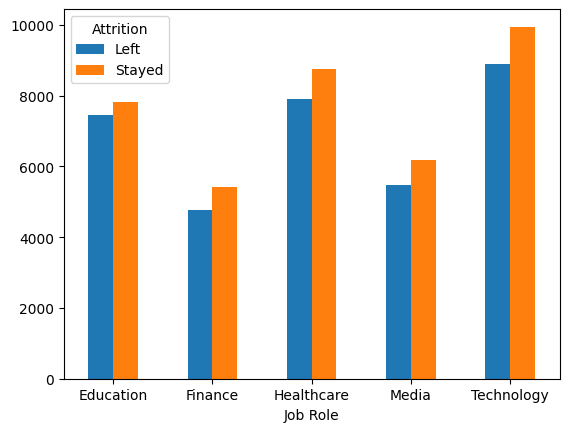

In [18]:
data.groupby('Job Role')['Attrition'].value_counts().unstack().plot(kind='bar')
plt.xticks(rotation=0)
plt.show()


In [19]:
data.columns

Index(['Age', 'Gender', 'Job Role', 'Monthly Income', 'Work-Life Balance',
       'Job Satisfaction', 'Performance Rating', 'Number of Promotions',
       'Overtime', 'Distance from Home', 'Remote Work',
       'Leadership Opportunities', 'Attrition', 'Tenure', 'Attrition Rate'],
      dtype='object')

In [20]:
X = data[['Age',
          'Gender',
          'Job Role',
        'Monthly Income',
        'Tenure',
        'Work-Life Balance',
        'Performance Rating',
        'Number of Promotions',
        'Job Satisfaction',
        'Overtime',
        'Distance from Home',
        'Leadership Opportunities'
        ]]

y = data['Attrition']

In [21]:
X = pd.get_dummies(X, drop_first=True)

In [22]:
!pip install scikit-learn

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [25]:
predictions = model.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.604503822050823


In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

        Left       0.59      0.56      0.58      6937
      Stayed       0.62      0.64      0.63      7584

    accuracy                           0.60     14521
   macro avg       0.60      0.60      0.60     14521
weighted avg       0.60      0.60      0.60     14521



In [28]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values(ascending=False)

Monthly Income                      0.198113
Distance from Home                  0.184720
Age                                 0.158496
Tenure                              0.151177
Number of Promotions                0.063585
Performance Rating_High             0.020823
Work-Life Balance_Fair              0.019580
Overtime_Yes                        0.018663
Job Satisfaction_Medium             0.018415
Work-Life Balance_Poor              0.016751
Gender_Male                         0.016321
Job Role_Technology                 0.015737
Job Role_Healthcare                 0.015729
Performance Rating_Below Average    0.015612
Job Satisfaction_Very High          0.015284
Job Role_Finance                    0.014199
Job Role_Media                      0.014012
Job Satisfaction_Low                0.012008
Work-Life Balance_Good              0.011498
Leadership Opportunities_Yes        0.010743
Performance Rating_Low              0.008535
dtype: float64